# Proiect: Optimizarea Eficienței Energetice în Clădirile Inteligente (UTCN Living Lab)

**Obiectivele principale:**
1. Curățarea datelor brute de la senzorii BEMS.
2. Identificarea echipamentelor mari folosind tehnici NILM (Non-Intrusive Load Monitoring).
3. Pregătirea datelor pentru predicția consumului (Feature Engineering).
4. Extragerea datelor externe (Electricity Maps / Transelectrica).
5. Simularea unor strategii de eficientizare: Load Shifting și reutilizarea căldurii (Data Center Heat Reuse).

## 1. Încărcarea Datelor
Vom importa bibliotecile necesare și vom încărca setul de date primit (`.csv`), setând coloana de timp ca index pentru a facilita analiza seriilor de timp (Time Series).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

cale_fisier = 'Fisierul .csv al tau :P'

try:
    print("Se incarca fisierul.:P")
    df = pd.read_excel(cale_fisier)

    df.columns = df.columns.str.strip()

    df.rename(columns={df.columns[0]: 'Date'}, inplace=True)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    df = df.dropna(subset=['Date'])
    df.set_index('Date', inplace=True)

    print("Fișierul a fost încărcat cu succes! Primele rânduri:")
    display(df.head())

except Exception as e:
    print(f"A apărut o eroare la încărcarea fișierului: {e}")

## 2. Curățarea Datelor și Calculul Consumului Auxiliar
Senzorii pot înregistra valori aberante (outliers) din cauza erorilor de comunicație.
* Vom aplica un filtru (Thresholding): valorile sub 0 kW și peste 2000 kW vor fi eliminate (NaN) și interpolate liniar.
* Vom calcula consumul auxiliar estimat pentru Clădire Baritiu și Instalatii scăzând consumatorii cunoscuți din consumul general.


In [ ]:
# totate id-urile pe care trebuie sa le curatam
toate_id_urile = ['ID_11', 'ID_12', 'ID_13', 'ID_14', 'ID_21', 'ID_22',
                  'ID_23', 'ID_24', 'ID_31', 'ID_32', 'ID_41', 'ID_42']

# Thresholding și Interpolare
for contor in toate_id_urile:
    if contor in df.columns:
        # valori aberante => NaN
        df.loc[(df[contor] > 2000) | (df[contor] < 0), contor] = np.nan
        # Interpolare valori lipsa pentru a avea o curba continua
        df[contor] = df[contor].interpolate(method='time')
        # umplere goluri
        df[contor] = df[contor].bfill().ffill()

#  calcul consum auxiliar
if all(col in df.columns for col in ['ID_11', 'ID_12', 'ID_13', 'ID_14']):
    df['Auxiliar_Cladirea_B'] = df['ID_11'] - (df['ID_12'] + df['ID_13'] + df['ID_14'])
    df.loc[df['Auxiliar_Cladirea_B'] < 0, 'Auxiliar_Cladirea_B'] = 0

if all(col in df.columns for col in ['ID_31', 'ID_32']):
    df['Auxiliar_Cladirea_I'] = df['ID_31'] - df['ID_32']
    df.loc[df['Auxiliar_Cladirea_I'] < 0, 'Auxiliar_Cladirea_I'] = 0

print("Datele au fost curățate, iar consumul auxiliar a fost calculat.")

## 3. Se etichetează Datele pentru NILM (Non-Intrusive Load Monitoring)
Pentru a antrena un algoritm care să detecteze echipamentele mari doar din consumul general (`ID_31`), este nevoie să se stabilească momentele clare în care chiller-ul a funcționat.
Se folosesc datele sub-contorului `ID_32` (Chiller Clădirea Instalatii) ca "Ground Truth" pentru a eticheta starea (ON/OFF).

In [ ]:
if 'ID_32' in df.columns and 'ID_31' in df.columns:
    # dacă se consumă mai mult de 5 kW, considerăm chiller-ul PORNIT (1), altfel OPRIT (0)
    df['Chiller_I_Status'] = (df['ID_32'] > 5).astype(int)

    fereastra = df.dropna().iloc[1000:1500]

    plt.figure(figsize=(15, 6))

    # Consumul general
    plt.plot(fereastra.index, fereastra['ID_31'], label='Consum General Instalații (ID_31)', color='blue')
    # Consumul izolat al Chiller-ului
    plt.plot(fereastra.index, fereastra['ID_32'], label='Consum Chiller Instalații (ID_32)', color='red')

    # Se evidențiează perioadele de funcționare
    plt.fill_between(fereastra.index, 0, fereastra['ID_31'].max(),
                     where=fereastra['Chiller_I_Status']==1,
                     color='gray', alpha=0.3, label='Perioada Chiller ON')

    plt.title('Identificarea funcționării Chiller-ului în Consumul General (NILM)')
    plt.xlabel('Timp')
    plt.ylabel('Putere (kW)')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## 4. Se extrag Caracteristicile pentru Machine Learning (Feature Engineering)
Consumul unei clădiri este puternic influențat de sezonalitate și programul de lucru uman. Pentru viitoarele modele de predicție, trebuie să se extragă componentele de timp din indexul Datetime.

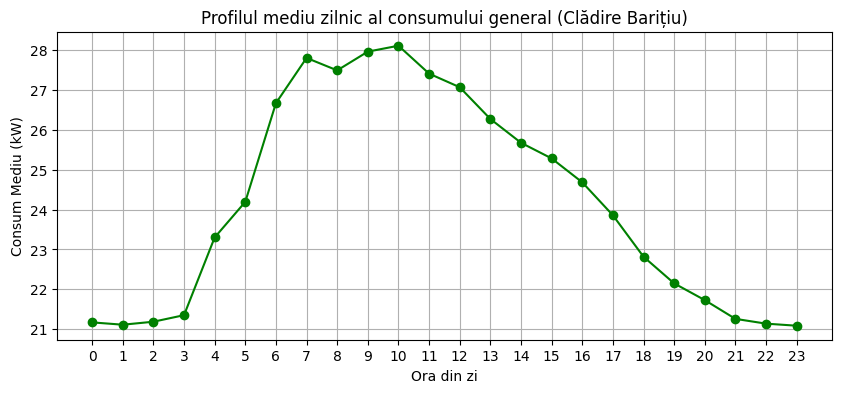

In [8]:
# ora, ziua, luna din index
df['Ora'] = df.index.hour
df['Ziua_Saptamanii'] = df.index.dayofweek # 0 = Luni, 6 = Duminică
df['Luna'] = df.index.month

# weekend sau nu
df['Este_Weekend'] = df['Ziua_Saptamanii'].apply(lambda x: 1 if x >= 5 else 0)

# profilul de consum orar pentru Clădire Barițiu
if 'ID_11' in df.columns:
    consum_mediu_orar = df.groupby('Ora')['ID_11'].mean()

    plt.figure(figsize=(10, 4))
    plt.plot(consum_mediu_orar.index, consum_mediu_orar.values, marker='o', color='green')
    plt.title('Profilul mediu zilnic al consumului general (Clădire Barițiu)')
    plt.xlabel('Ora din zi')
    plt.ylabel('Consum Mediu (kW)')
    plt.xticks(range(0, 24))
    plt.grid(True)
    plt.show()

## 5. Se extrag Datele Externe (Electricity Maps API)
Pentru strategiile de optimizare ("Load Shifting"), este nevoie de vizibilitate asupra rețelei naționale (SEN). Se face conectarea la API-ul Electricity Maps pentru a putea prelua prognoza prețurilor sau a intensității carbonului.

In [ ]:
import requests
import pandas as pd

API_KEY = 'API_KEY'

def obtine_date_retea(api_key, zona='RO'):
    # Se folosește API-ul pentru a cere prognoza intensității emisiilor de carbon pentru România
    url = f"https://api.electricitymap.org/v3/carbon-intensity/forecast?zone={zona}"
    headers = {"auth-token": api_key}

    try:
        response = requests.get(url, headers=headers)

        if response.status_code == 200:
            date_api = response.json()
            prognoza_df = pd.DataFrame(date_api['forecast'])
            prognoza_df['datetime'] = pd.to_datetime(prognoza_df['datetime'])
            prognoza_df.set_index('datetime', inplace=True)
            return prognoza_df
        else:
            print(f"Eroare API. Cod de status: {response.status_code}. (Verifică dacă cheia API este corectă!)")
            return None

    except Exception as e:
        print(f"Eroare la conexiunea API: {e}")
        return None

date_retea = obtine_date_retea(API_KEY)

if date_retea is not None:
    print("Datele de pe Electricity Maps au fost descărcate cu succes!")
    display(date_retea.head())

## 6. Concepte de Optimizare: Load Shifting și Heat Reuse
Se definesc funcțiile logice prin care algoritmul AI va lua decizii în timp real:
1. **Load Shifting:** Decalarea funcționării HVAC pentru a evita orele cu energie scumpă.
2. **Heat Reuse:** Evaluarea cantității de căldură disipată de Data Center (`ID_12`) pentru a reduce sarcina Centralei Termice (`ID_22`).

In [ ]:
def strategia_load_shifting(ora, pret_energie_estimat, temp_clasa):
    """
    Mai jos apare o logică de bază pentru Load Shifting.
    (Scheletele va fi înlocuit de partea cu Machine Learning)
    """
    PRET_MARE = 500
    PRET_MIC = 200

    if pret_energie_estimat >= PRET_MARE and temp_clasa < 25:
        # dacă e vârf de sarcină, dar clădirea e deja răcoroasă, oprim consumatorul
        return "OFF (Shifted)"
    elif pret_energie_estimat <= PRET_MIC and 12 <= ora <= 16:
        # pre-răcire când energia e ieftină/verde
        return "ON (Pre-Cooling)"
    else:
        return "AUTO (Termostat)"

def calcul_reutilizare_caldura(consum_servere_kw):
    """
    1 kW consumat de echipamentele IT generează aprox. 1 kW de căldură disipată.
    Returnează câtă energie poate fi redusă teoretic de la centrala termică.
    """
    EFICIENTA_RECUPERARE = 0.8 # Se presupune că 80% din aerul cald poate fi captat
    caldura_recuperata_kw = consum_servere_kw * EFICIENTA_RECUPERARE
    return caldura_recuperata_kw

# Exemplu de test folosind o valoare de la ID_12/servere
if 'ID_12' in df.columns:
    consum_servere_mediu = df['ID_12'].mean()
    caldura_salvata = calcul_reutilizare_caldura(consum_servere_mediu)
    print(f"La un consum mediu al serverelor de {consum_servere_mediu:.2f} kW,")
    print(f"se pot recupera aprox. {caldura_salvata:.2f} kW putere termică.")